# Social choice assignment project CAI

We will analyse the dataset 00073-00000002.cat regarding the 2017 categorization of French electoral candidates. We will do this by applying various social choice voting rules and construct & evaluate their social choice functions. 

The data is categorical, with a ranking within the categories (1, 0, -1) possibly representing approve, neutral, disapprove. Many candidates may be ranked in any category. So then, we must count their category as their preference ranking and cannot assume any ranking within a preference category. 

## Loading the Data into Python

In [31]:
import re

def load_cat(filepath):
    metadata = {}
    ballots = []

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Metadata
            if line.startswith('#'):
                if ':' in line:
                    key, value = line[1:].split(':', 1)
                    metadata[key.strip()] = value.strip()
                continue

            # Skip lines that don't look like ballots
            if ':' not in line:
                continue

            count_str, prefs_str = line.split(':', 1)
            count = int(count_str.strip())

            groups = re.findall(r'\{([^}]*)\}', prefs_str)
            ranking = [
                {int(x.strip()) for x in group.split(',') if x.strip()}
                for group in groups
            ]

            ballots.append({
                "count": count,
                "ranking": ranking
            })


    return metadata, ballots

In [32]:
metadata, ballots = load_cat("00073-00000002.cat")

total_voters = metadata.get("NUMBER VOTERS", "Unknown")
print(f"Total voters: {total_voters}")

alternatives = metadata.get("NUMBER ALTERNATIVES", "Unknown")
print(f"Number of alternatives: {alternatives}")

print(ballots[0])

Total voters: 13197
Number of alternatives: 11
{'count': 238, 'ranking': [{10, 6}, {1, 11, 9}, {2, 3, 4, 5, 7, 8}]}


The count defines our score value in the scoring vector, while the ranking (preferences) have been stores in the ranking attribute. 

# Plurality Rule

We choose the best candidate by the number of times they are number 1 in the preferences. Hence this is the scoring rule with the scoring vector s = (1, 0,0,.., 0) for the U (universe of alternatives in the preferences). However, we will only look at the best category, so hence we can look at how many times each alternative (candidate) is in the category 1. To implement this scoring rule we apply for each preference casted, this score vector. 

In [33]:
def plurality_rule_SCF(ballots):
    scores = {}
    for ballot in ballots:
        count = ballot["count"]
        ranking = ballot["ranking"]
        if ranking:
            top_group = ranking[0]
            for candidate in top_group:
                scores[candidate] = scores.get(candidate, 0) + count
    max_score = max(scores.values())
    print(scores)
    winners = [candidate for candidate, score in scores.items() if score == max_score]
    return winners

In [34]:
plurality_winner_idx = plurality_rule_SCF(ballots)

for idx in plurality_winner_idx:
    print(metadata[f"ALTERNATIVE NAME {idx}"])

{10: 8621, 6: 8208, 1: 3308, 11: 5449, 9: 3985, 2: 1253, 3: 1327, 4: 1666, 5: 1437, 7: 2160, 8: 854}
Jean-Luc Mélenchon


# Anti - Plurality Rule (Veto Rule)

For the anti-plurality rule we reward alternatives who are not last, with a scoring vector of (1,1,...,0). We can thus find out how many times each alternative falls in the final category and then award the ones who do this least with the winner title. 


In [35]:
# anti_plurality_score_vector = [1 if i < alternatives else 0 for i in range(alternatives)]
def anti_plurality_rule_SCF(ballots):
    scores = {}
    for ballot in ballots:
        count = ballot["count"]
        ranking = ballot["ranking"]
        if ranking:
            bottom_group = ranking[-1]
            for candidate in bottom_group:
                scores[candidate] = scores.get(candidate, 0) + count
    min_score = min(scores.values())
    print(scores)
    winners = [candidate for candidate, score in scores.items() if score == min_score]
    return winners

In [36]:
anti_plurality_winner_idx = anti_plurality_rule_SCF(ballots)
for idx in anti_plurality_winner_idx:
    print(metadata[f"ALTERNATIVE NAME {idx}"])

{2: 8643, 3: 7525, 4: 8446, 5: 9711, 7: 5894, 8: 10800, 9: 4586, 1: 4508, 11: 3484, 10: 1711, 6: 1682}
Benoît Hamon


# Borda's Rule

With Borda's rule we award the alternatives by their rank. Hence the scoring vector is s = (n-1, n-2, ..., 0). We have 3 categorical ranks, so we have (2, 1, 0) and we will award each alternative falling into a rank with the scoring[rank] value

In [37]:
# borda_score_vector = [2, 1, 0]
def borda_rule_SCF(ballots):
    scores = {}
    for ballot in ballots:
        count = ballot["count"]
        ranking = ballot["ranking"]
        num_groups = len(ranking)
        for i, group in enumerate(ranking):
            points = num_groups - i - 1
            for candidate in group:
                scores[candidate] = scores.get(candidate, 0) + points * count
    max_score = max(scores.values())
    print(scores)
    winners = [candidate for candidate, score in scores.items() if score == max_score]
    return winners

In [38]:
borda_winner_idx = borda_rule_SCF(ballots)
for idx in borda_winner_idx:
    print(metadata[f"ALTERNATIVE NAME {idx}"])

{10: 15676, 6: 15216, 1: 8574, 11: 11431, 9: 8799, 2: 3258, 3: 4327, 4: 3807, 5: 2464, 7: 6397, 8: 1204}
Jean-Luc Mélenchon


So far, the 3 scoring rules do not finding the condorcet winner in some preference profiles. Hence we will consider a condorcet extension too. 

# Copeland's Rule

Copeland's rule awards an alternative for a pairwaise result, win, lose or tie. Here we will consider the ties within a category to count as well with a value between 0 and 1. 

Copeland Scores (tie_value=0.5): {1: 7, 2: 2, 3: 4, 4: 3, 5: 1, 6: 9, 7: 5, 8: 0, 9: 6, 10: 10, 11: 8}
Jean-Luc Mélenchon
Detailed Copeland Scores for Different Tie Values


<Figure size 432x288 with 0 Axes>

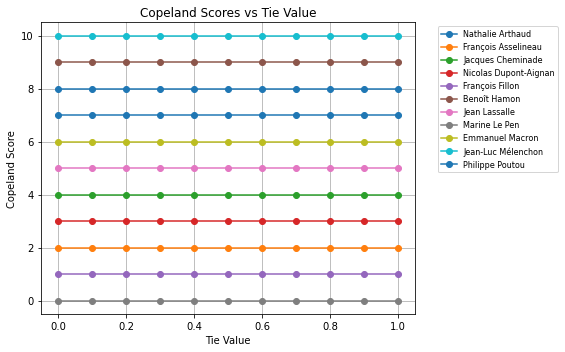

In [ ]:
# Copeland's Rule
# A Condorcet extension method based on pairwise majority matchups (1v1).
# Candidates get 1 point for every other candidate they beat in a 1v1 matchup, 
# 0 points for a loss, and 'tie_value' points for an overall tie.

def copeland_rule_SCF(ballots, tie_value=0.5):
    # Step 1: Extract all unique candidates from the ballots
    candidates = set()
    for ballot in ballots:
        for group in ballot["ranking"]:
            candidates.update(group)
    candidates = list(candidates)
    
    # Initialize Copeland scores for all candidates to 0
    copeland_scores = {candidate: 0 for candidate in candidates}

    # Step 2: Conduct pairwise majority matchups (1v1) for every pair of candidates
    for i in range(len(candidates)):
        for j in range(i + 1, len(candidates)):
            candidate_i = candidates[i]
            candidate_j = candidates[j]
            
            # Tally the total number of voters who prefer i to j, and j to i
            votes_for_i = 0
            votes_for_j = 0

            for ballot in ballots:
                count = ballot["count"]
                ranking = ballot["ranking"]
                
                # Find the rank index for each candidate (lower index = better preference)
                # If a candidate is missing from the ballot, assign infinity (float('inf'))
                position_i = next((idx for idx, group in enumerate(ranking) if candidate_i in group), float('inf'))
                position_j = next((idx for idx, group in enumerate(ranking) if candidate_j in group), float('inf'))

                if position_i < position_j:
                    votes_for_i += count
                elif position_j < position_i:
                    votes_for_j += count
                # Note: if position_i == position_j, it's a tie on this specific ballot, 
                # so neither candidate gets an advantage from these specific voters.
            # Step 3: Award Copeland points based on the final 1v1 matchup result
            if votes_for_i > votes_for_j:
                copeland_scores[candidate_i] += 1  # Candidate i wins the matchup
            elif votes_for_j > votes_for_i:
                copeland_scores[candidate_j] += 1    # Candidate j wins the matchup
            else:
                copeland_scores[candidate_i] += tie_value # Overall tie
                copeland_scores[candidate_j] += tie_value # Overall tie

    # Step 4: Determine the winner(s) with the maximum Copeland score
    max_score = max(copeland_scores.values())
    formatted_scores = {k: round(v, 1) for k, v in copeland_scores.items()}
    print(f"Copeland Scores (tie_value={tie_value}): {formatted_scores}")
    winners = [candidate for candidate, score in copeland_scores.items() if score == max_score]
    return winners

copeland_winner_idx = copeland_rule_SCF(ballots, tie_value=0.5)
for idx in copeland_winner_idx:
    print(metadata[f"ALTERNATIVE NAME {idx}"])

# Lets change the value of tie_value and see how it affects the scores and winner
tie_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
copeland_winners = {}

print("Detailed Copeland Scores for Different Tie Values")
import matplotlib.pyplot as plt

copeland_history = {}

for tie in tie_values:
    
    candidates = set()
    for ballot in ballots:
        for group in ballot["ranking"]:
            candidates.update(group)
    candidates = list(candidates)
    
    copeland_scores = {candidate: 0 for candidate in candidates}

    for i in range(len(candidates)):
        for j in range(i + 1, len(candidates)):
            candidate_i = candidates[i]
            candidate_j = candidates[j]
            votes_for_i = 0
            votes_for_j = 0

            for ballot in ballots:
                count = ballot["count"]
                ranking = ballot["ranking"]
                position_i = next((idx for idx, group in enumerate(ranking) if candidate_i in group), float('inf'))
                position_j = next((idx for idx, group in enumerate(ranking) if candidate_j in group), float('inf'))

                if position_i < position_j:
                    votes_for_i += count
                elif position_j < position_i:
                    votes_for_j += count

            if votes_for_i > votes_for_j:
                copeland_scores[candidate_i] += 1
            elif votes_for_j > votes_for_i:
                copeland_scores[candidate_j] += 1
            else:
                copeland_scores[candidate_i] += tie
                copeland_scores[candidate_j] += tie
    copeland_history[tie] = copeland_scores


plt.figure()

plt.figure(figsize=(8,5))

for candidate in candidates:
    scores = [copeland_history[tie][candidate] for tie in tie_values]
    label = metadata[f"ALTERNATIVE NAME {candidate}"]
    plt.plot(tie_values, scores, marker='o', label=label)

plt.xlabel("Tie Value")
plt.ylabel("Copeland Score")
plt.title("Copeland Scores vs Tie Value")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid()
plt.tight_layout()

plt.show()


# Single transferable vote (STV)


We look at the alternative that is winning (First place) the least and remove. We continue this process till we have a winner. Everytime we remove an agent, we must only drop that agent from all preferences. This way, other agents, in 2nd or lower places may end up surviving till the end. 

In [41]:
def tally_first(ballots):
    # Let us tally the 1st place (1st category) wins for each candidate
    first_place_counts = {}
    for ballot in ballots:
        count = ballot["count"]
        ranking = ballot["ranking"]
        if ranking:
            top_group = ranking[0]
            for candidate in top_group:
                first_place_counts[candidate] = first_place_counts.get(candidate, 0) + count
    return first_place_counts

# we find the candidate(s) with the least 1st place votes and eliminate them, then we repeat the process until one candidate remains
def single_transferable_vote_SCF(ballots):
    remaining_candidates = set()
    for ballot in ballots:
        for group in ballot["ranking"]:
            remaining_candidates.update(group)

    while len(remaining_candidates) > 1:
        first_place_counts = tally_first(ballots)
        min_count = min(first_place_counts[candidate] for candidate in remaining_candidates)
        candidates_to_eliminate = [candidate for candidate in remaining_candidates if first_place_counts[candidate] == min_count]
        print(f"Eliminating candidates: {[metadata[f'ALTERNATIVE NAME {idx}'] for idx in candidates_to_eliminate]} with {min_count} first-place votes")
        # Eliminate candidates
        remaining_candidates -= set(candidates_to_eliminate)

        # Remove eliminated candidates from ballots
        new_ballots = []
        for ballot in ballots:
            count = ballot["count"]
            ranking = ballot["ranking"]
            new_ranking = []
            for group in ranking:
                new_group = {candidate for candidate in group if candidate in remaining_candidates}
                if new_group:
                    new_ranking.append(new_group)
            if new_ranking:
                new_ballots.append({"count": count, "ranking": new_ranking})
        ballots = new_ballots

    return list(remaining_candidates)   

In [42]:
stv_winner_idx = single_transferable_vote_SCF(ballots)
for idx in stv_winner_idx:
    print(metadata[f"ALTERNATIVE NAME {idx}"])

Eliminating candidates: ['Marine Le Pen'] with 854 first-place votes
Eliminating candidates: ['François Asselineau'] with 1447 first-place votes
Eliminating candidates: ['Jacques Cheminade'] with 1547 first-place votes
Eliminating candidates: ['François Fillon'] with 1675 first-place votes
Eliminating candidates: ['Nicolas Dupont-Aignan'] with 1938 first-place votes
Eliminating candidates: ['Jean Lassalle'] with 2608 first-place votes
Eliminating candidates: ['Nathalie Arthaud'] with 3794 first-place votes
Eliminating candidates: ['Emmanuel Macron'] with 4610 first-place votes
Eliminating candidates: ['Philippe Poutou'] with 6367 first-place votes
Eliminating candidates: ['Benoît Hamon'] with 9564 first-place votes
Jean-Luc Mélenchon


# Is there a Condorcet Winner

In [43]:
def condorcet_winner_SCF(ballots):
    candidates = set()
    for ballot in ballots:
        for group in ballot["ranking"]:
            candidates.update(group)

    candidates = sorted(candidates)
    pairwise_wins = {candidate: 0 for candidate in candidates}

    for i in range(len(candidates)):
        for j in range(i + 1, len(candidates)):
            candidate_i = candidates[i]
            candidate_j = candidates[j]
            votes_for_i = 0
            votes_for_j = 0

            for ballot in ballots:
                count = ballot["count"]
                ranking = ballot["ranking"]
                position_i = next((idx for idx, group in enumerate(ranking) if candidate_i in group), float('inf'))
                position_j = next((idx for idx, group in enumerate(ranking) if candidate_j in group), float('inf'))

                if position_i < position_j:
                    votes_for_i += count
                elif position_j < position_i:
                    votes_for_j += count

            if votes_for_i > votes_for_j:
                pairwise_wins[candidate_i] += 1
            elif votes_for_j > votes_for_i:
                pairwise_wins[candidate_j] += 1

    num_candidates = len(candidates)
    winners = [candidate for candidate, wins in pairwise_wins.items() if wins == num_candidates - 1]
    return winners

In [44]:
condorcet_winner_idx = condorcet_winner_SCF(ballots)
for idx in condorcet_winner_idx:
    print(metadata[f"ALTERNATIVE NAME {idx}"])

Jean-Luc Mélenchon
